# HW 14 - Astropy
ULAB - Physics and Astronomy Division \
Due **Sunday, March 1st, 2025 at 11:59pm** on Gradescope

## 1 Unit Conversion
Import the astropy module `units` as `u` in the cell below.

In [7]:
# Your code here
import astropy.units as u

Convert a speed of **60 km/h** to **m/s**. \
\
Round your answer to two significant digits. *Hint: With an f-string, you can use `:.3f`, like `print(f"{speed_mps:.3f}")`*.

In [12]:
# Your code here
speed_kmh = 60 * u.kilometer / u.hour
speed_mps = speed_kmh.to(u.meter / u.second)
print(f'{speed_mps:.2g}')

17 m / s


## 2 Time Manipulation
Define **Julian Date** in the cell below.

In [13]:
# Your comment here
'''
Julian Date is a cool way for astronomers to keep track of days. This counts the number of days since a certain point in time and is just 
another way of keepng track of time. 
'''

'\nJulian Date is a cool way for astronomers to keep track of days. This counts the number of days since a certain point in time and is just \nanother way of keepng track of time. \n'

What's the difference between the **Julian calendar** and the **Gregorian calendar**?

In [14]:
# Your comment here
'''
Gregorian Calendar is based on a system of years, months, and days of the months. The Julian Calendar is simply a count of the number of
days so this can just be represented as a single integer and can count the number of days since a specific date.
'''

'\nGregorian Calendar is based on a system of years, months, and days of the months. The Julian Calendar is simply a count of the number of\ndays so this can just be represented as a single integer and can count the number of days since a specific date.\n'

From the astropy module `time` import `Time` in the cell below.

In [16]:
# Your code here
from astropy.time import Time

Find the Julian Date for **the current time**. 

In [17]:
# Your code here
julian_date = Time.now().jd
print(julian_date)

2460735.852272838


Convert `1969-07-02 20:17:00` to its **Julian Date**.

In [19]:
# Your code here
time = Time('1969-07-02 20:17:00').jd
print(time)

2440405.345138889


What historically happened at this date and time?

In [21]:
# Your comment here 
'''
I assume this means the 20th of july, not the 2nd since on this day/time was the first moon landing when the goats Neil Armstrong and 
Buzz Aldrin first stepped on the moon.
'''

'\nI assume this means the 20th of july, not the 2nd since on this day/time was the first moon landing when the goats Neil Armstrong and \nBuzz Aldrin first stepped on the moon.\n'

## 3 Coordinate Transformations
From the astropy module `coordinates` import `SkyCoord`, `Galactic`, `AltAz` and `EarthLocation` in the cell below.

In [23]:
# Your code here 
from astropy.coordinates import SkyCoord, Galactic, AltAz, EarthLocation

Define a celestial object at **RA = 15 degrees** and **DEC = -20 degrees** in ICRS. Use the astropy `Time` module.

In [31]:
# Your code here
object = SkyCoord(ra=15 * u.degree, dec = -20*u.degree)
time=Time.now()
print(object)

<SkyCoord (ICRS): (ra, dec) in deg
    (15., -20.)>


Convert the object's coordinates from ICSRS to **Galactic**.

In [32]:
# Your code here
object_galactic = object.galactic
print(object_galactic)

<SkyCoord (Galactic): (l, b) in deg
    (138.76123783, -82.60718782)>


Convert the object's coordinate from ICRS to **AltAz**. For AltAz frame, use the location of **Campbell Hall**.

In [37]:
# Your code here
campbell = EarthLocation(lat=37.873161*u.degree, lon=-122.257194*u.degree)
altaz = object.transform_to(AltAz(obstime=time, location = campbell))
print(altaz)

<SkyCoord (AltAz: obstime=2025-03-01 08:43:31.504113, location=(-2690531.22676248, -4263047.7475985, 3894340.35053798) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron): (az, alt) in deg
    (299.61541535, -60.28606847)>


## 4 FITS Files
From the astropy module `astropy.io` import `fits` in the cell below.

In [30]:
# Your code here
from astropy.io import fits

From the astropy module `astropy.utils.data` import `download_file`.

In [38]:
# Your code here
from astropy.utils.data import download_file

Import `numpy` in the cell below.

In [39]:
# Your code here
import numpy as np

Use the `download_file` astropy function to create a variable for the location of the `.fits` file from class.

In [40]:
image_file = download_file('http://data.astropy.org/tutorials/FITS-images/HorseHead.fits', cache=True)

Follow the procedure from lecture to open the `.fits` files in the cell below. Make sure to use the `hdul` format, while calling `hdul.info`, `hdul[0]` and `hdul[1]` appropriately.

In [56]:
# Your code here
with fits.open(image_file) as hdul:
    hdul.info() # Displaying stuff in our file
    data = hdul[0].data # Getting primary data
    header=hdul[0].header # Getting header information

Filename: /Users/manank/.astropy/cache/download/url/ff6e0b93871033c68022ca026a956d87/contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   (891, 893)   int16   
  1  er.mask       1 TableHDU        25   1600R x 4C   [F6.2, F6.2, F6.2, F6.2]   


With the `np.max` function, find the brightest pixel in the image. Print its value in the cell below.

In [57]:
# Your code here
print(np.max(data))

22918


With the `np.min` function, find the least brightest pixel in the image. Print its value in the cell below.

In [58]:
# Your code here
print(np.min(data))

3759


## Tables
From the astropy module `astropy.table` import `Table`.

In [69]:
# Your code here
from astropy.table import Table

Make an astropy table with **three** actual stars (so you will need to use google for this part). Include the `name`, `magnitude` and `spectral type`.

In [70]:
# Your code here
rows = [('Rigel', -7.84, 'B8'),('Vega', 0.582, 'A0'), ('Pollux',1.08,'K0')]
stars = Table(rows=rows, names=('name', 'magnitude', 'spectral type'))
print(stars)

 name  magnitude spectral type
------ --------- -------------
 Rigel     -7.84            B8
  Vega     0.582            A0
Pollux      1.08            K0


Save the table as a `.fits` file. *Hint: Use the function `.write` with the argument `format='fits'`.*

In [163]:
# Your code here
stars.write('stars_fits.fits', overwrite=True)

Read and print the table in the cell below from the `.fits` file you made.

In [164]:
# Your code here
stars_fits = Table.read('stars_fits.fits')
print(stars_fits)

 name  magnitude spectral type
------ --------- -------------
 Rigel     -7.84            B8
  Vega     0.582            A0
Pollux      1.08            K0


## 6 Advanced... but awesome!
With the Hipparcos catalog, construct a Hertzsprung-Russell (H-R) diagram. Overall you will do the following:
* Download and clean the stellar data from the Hipparcos catalog.
* Calculate the absolute magnitude of the stars.
* Convert and classify spectral types.
* Plot an H-R diagram using both spectral class and color-index (B-V).

In the cell below, define what an **H-R** diagram is.

In [131]:
# Your comment here
'''
A Hertzsprung-Russell Diagram plots the relationship between temperature and luminosities/absolute magnitude. When these are plotted,
you can start to see some patterns such as the main sequence branch or the white dwarf cluster.
'''

'\nA Hertzsprung-Russell Diagram plots the relationship between temperature and luminosities/absolute magnitude. When these are plotted,\nyou can start to see some patterns such as the main sequence branch or the white dwarf cluster.\n'

### 6.1 Download and Load in the Hipparcos Catalog
The catalog you are downloading contains accurate parallax measurements which will help us determine the **absolute magnitude** of stars. 
* **Absolute mangitude** = the actual brightness of a star
* **Apparent magnitude** = how bright the star appears to us on Earth

Import `pandas` in the cell below.

In [132]:
# Your code here
import pandas as pd

In the cell below import the file `cluster_data.csv` as a pandas dataframe. Add the following arguments:
* skiprows=44
* sep=';'
* header=None
* index_col=0
* names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType']
* skipfooter=1
* engine='python'

In [133]:
# Your code here
df = pd.read_csv('cluster_data.tsv', skiprows=44,sep=';',header=None, index_col = 0, names=['HIP','Vmag', 'Plx', 'B-V', 'SpType'],skipfooter=1, engine='python')

Display the first few rows of the data.

In [134]:
# Your code here
print(df.head(5))

      Vmag      Plx     B-V SpType
HIP                               
10    8.59    10.76   0.489    F6V
11    7.34     4.29   0.081     A2
12    8.43     4.06   1.484  K4III
13    8.80     3.49   1.128  K0III
14    7.25     5.11   1.200     K0


### 6.2 Clean the Data
Some of the rows in the data contain **missing** or **invalid** values so we need to "clean" our data. We will start by replacing the **blank spaces with NaN**, run the cell below.

In [135]:
df_clean = df.map(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)

Drop the rows with missing (NaN) values. *Hint: Use the `.dropna()` function`.

In [136]:
# Your code here
df_clean = df_clean.dropna()

Run the cell below. We are converting the datatypes in the columns to floats.

In [137]:
df_clean[['Vmag', 'Plx', 'B-V']] = df_clean[['Vmag', 'Plx', 'B-V']].astype(float)

# Display dataset summary
print(df_clean.describe())

                Vmag            Plx            B-V
count  114463.000000  114463.000000  114463.000000
mean        8.297699       7.104872       0.702415
std         1.248614      11.064009       0.490235
min        -1.440000     -35.100000      -0.400000
25%         7.610000       2.520000       0.341000
50%         8.400000       4.580000       0.605000
75%         9.070000       8.260000       1.075000
max        13.610000     772.330000       5.460000


### 6.3 Compute Absolute Magnitude
The absolute magnitude ($M_V$) of a star is given by:

$$
M_V = V_{\text{mag}} + 5 \cdot \log_{10}\left(\frac{\text{Plx}}{100}\right)
$$

Run the cell below.

In [138]:
df_clean['M_V'] = df_clean['Vmag'] + 5 * np.log10(df_clean['Plx'] / 100)
print(df_clean[['Vmag', 'Plx', 'M_V']].head())

     Vmag    Plx       M_V
HIP                       
10   8.59  10.76  3.749061
11   7.34   4.29  0.502286
12   8.43   4.06  1.472630
13   8.80   3.49  1.514127
14   7.25   5.11  0.792105


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Describe what the cell above is doing. 

In [139]:
# Your comment here
'''
The above code is converting the visual (or apparent) magnitude to absolute magnitude through the distance modulus probably.
'''

'\nThe above code is converting the visual (or apparent) magnitude to absolute magnitude through the distance modulus probably.\n'

### 6.4 Process the Spectral Types
Stars are defined by their spectral types:
* The first letter (O, B, A, F, G, K, M) indicates the **temperature** of a star.
* The digit (0-9) refines the **classification**.

Now we will extract the first two characters for sorting purposes. Run the cell below.

In [140]:
# Extract the first two characters (e.g., 'G2', 'K3')
df_clean['SpType2'] = df_clean['SpType'].str[:2]

# Keep only valid spectral classes
df_clean = df_clean[df_clean['SpType2'].str.match(r'^[OBAFGKM][0-9]')]

# Display unique spectral types
print(df_clean['SpType2'].unique())

['F6' 'A2' 'K4' 'K0' 'K2' 'F3' 'K5' 'G5' 'G0' 'G8' 'F2' 'G3' 'F7' 'A0'
 'B8' 'F0' 'G6' 'G9' 'K1' 'K3' 'F5' 'G1' 'A4' 'G2' 'B5' 'B9' 'M0' 'F8'
 'M1' 'G7' 'M2' 'B0' 'B7' 'A9' 'M3' 'A3' 'O7' 'A1' 'B4' 'A6' 'B3' 'B2'
 'A5' 'M4' 'A7' 'O8' 'M5' 'G4' 'K7' 'B1' 'O6' 'M6' 'F4' 'A8' 'K8' 'M7'
 'B6' 'O9' 'F9' 'M8' 'M9' 'K9' 'O5' 'F1' 'K6' 'O4']


What letter represents the **hottest** stars? What letter represents the **coldest** stars?

In [141]:
# Your comment here
'''
O represents the hottest starrs, M represents the coldest stars
'''

'\nO represents the hottest starrs, M represents the coldest stars\n'

### 6.5 Plot the H-R Diagram(s)
Conver the spectral types into sortable numerical categories. Run the cell below.

In [142]:
order = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
df_clean['SpType2_numeric'] = df_clean['SpType2'].apply(lambda x: order[x[0]]*10 + int(x[1]))

Import `matplotlib.pyplot` in the cell below.

In [143]:
# Your code here
import matplotlib.pyplot as plt

**Spectral Type vs. Absolute Magnitude** \
Scatter the `df_clean['SpType2_numeric']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(0, 70).
* Set a `ylim` of `(15, -10).
* Call `xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])`.
* Call `xticks(range(5,75,10))`.
* Title the x-axis `'Spectral Type'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

Text(0.5, 1.0, 'H-R Diagram (Hipparcos Catalog)')

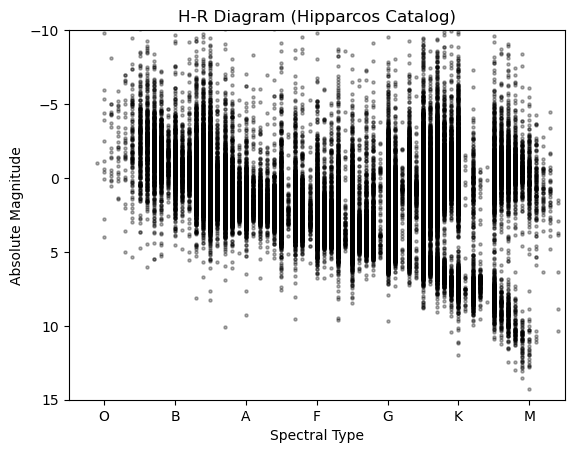

In [147]:
# Your code here
plt.scatter(x=df_clean['SpType2_numeric'], y=df_clean['M_V'],s=5,alpha=0.3, c='k')
plt.xlim(0,70)
plt.ylim(15,-10)
plt.xticks(ticks=range(5,75,10), labels=['O', 'B', 'A', 'F', 'G', 'K', 'M'])
plt.xlabel('Spectral Type')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram (Hipparcos Catalog)')


**Color Index (B-V) vs. Absolute Magnitude** \
Scatter the `df_clean['B-V']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(-0.5, 2.5).
* Set a `ylim` of `(15, -10).
* Title the x-axis `'Color Index (B-V)'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

Text(0.5, 1.0, 'H-R Diagram (Hipparcos Catalog)')

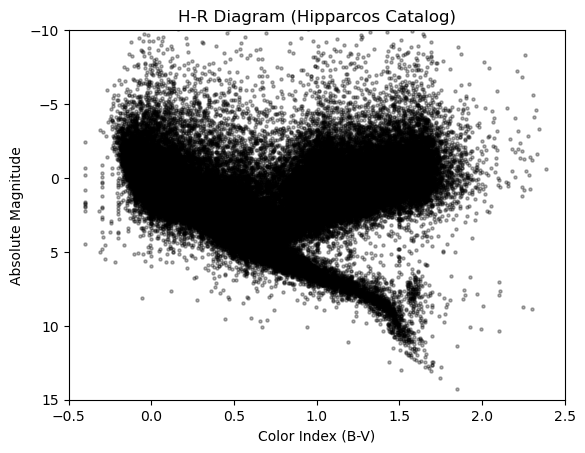

In [148]:
# Your code here
plt.scatter(x=df_clean['B-V'], y=df_clean['M_V'],s=5,alpha=0.3, c='k')
plt.xlim(-0.5,2.5)
plt.ylim(15,-10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram (Hipparcos Catalog)')

### 6.6 Highlight Luminosity Classes
Great! Finally, we want to difference between our three main luminosity classes:
* Main Sequence (V), aka what our sun is
* Giants (III)
* Supergiants(I)

Run the cell below.

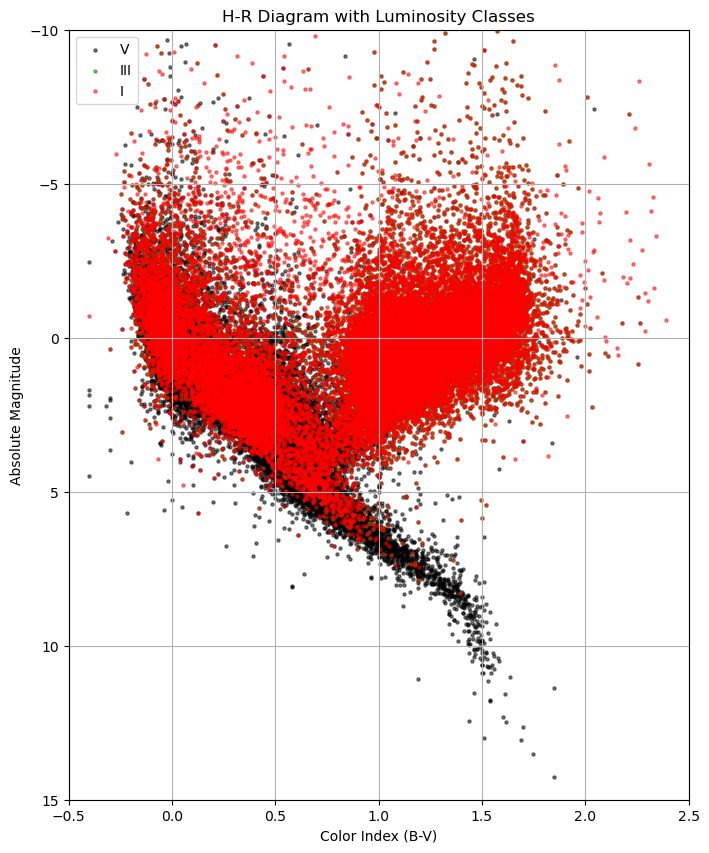

In [149]:
def plot_luminosity_class(df, label, color):
    mask = df['SpType'].str.contains(label, na=False)
    plt.scatter(df[mask]['B-V'], df[mask]['M_V'], s=5, label=label, c=color, alpha=0.5)

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants

plt.legend()
plt.show()


With the example above, now plot the following types **WITH** and then **WITHOUT** the ones above:
* Subdwarfs (VI)
* White dwarfs (VII)
* Subgiants (IV)
* Bright giants (II)

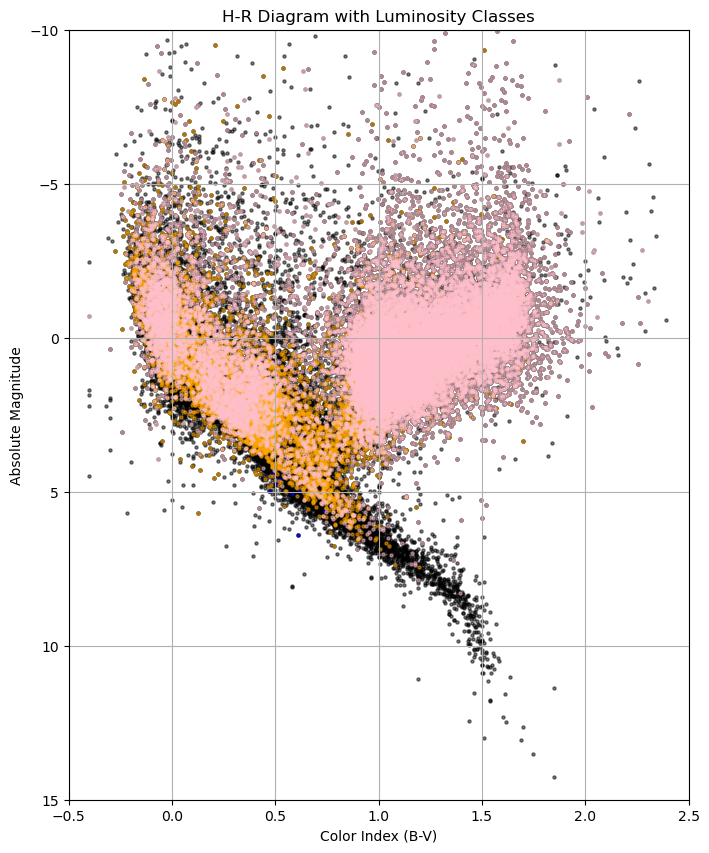

In [161]:
# Your code here
plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')
plot_luminosity_class(df_clean, 'I', 'Black')
plot_luminosity_class(df_clean, 'III', 'Black')
plot_luminosity_class(df_clean, 'V', 'Black')
plot_luminosity_class(df_clean, 'VI', 'Blue')
plot_luminosity_class(df_clean, 'VII', 'Green')
plot_luminosity_class(df_clean, 'IV', 'Orange')
plot_luminosity_class(df_clean, 'II', 'Pink')

'\nProbably no white dwarfs in the data set ig\n'

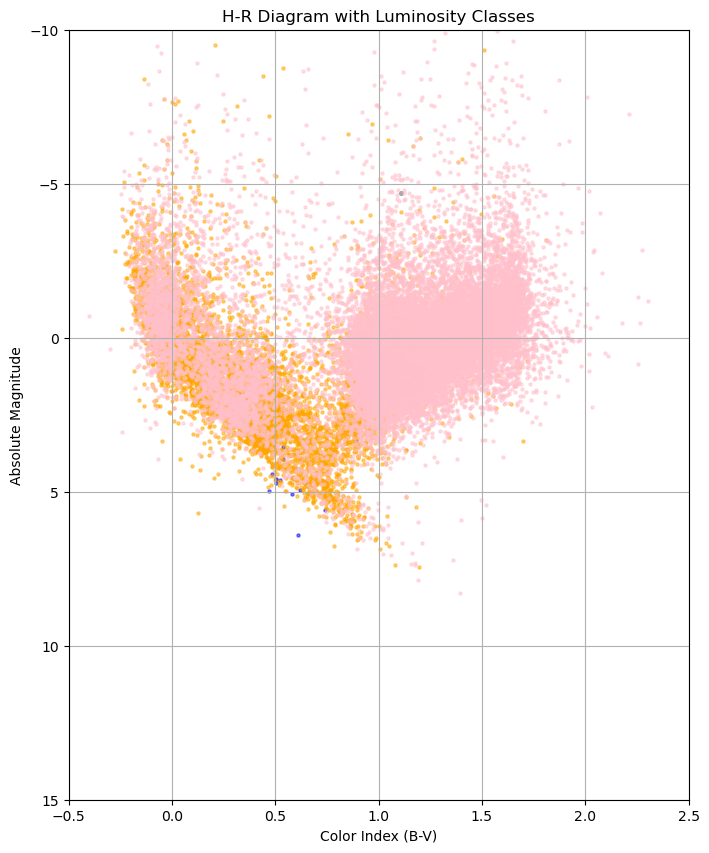

In [160]:
# Your code here
plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')
plot_luminosity_class(df_clean, 'VI', 'Blue')
plot_luminosity_class(df_clean, 'VII', 'Green')
plot_luminosity_class(df_clean, 'IV', 'Orange')
plot_luminosity_class(df_clean, 'II', 'Pink')
'''
Probably no white dwarfs in the data set ig
'''

Submit your FITS file and this notebook to Gradescope!